In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('./loan.csv')

/tmp/ipykernel_11795/2590826474.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./loan.csv')


In [6]:
df.shape
df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,92187,92174,2500,2500,1075.0,36 months,8.07%,78.42,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39713,90665,90607,8500,8500,875.0,36 months,10.28%,275.38,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39714,90395,90390,5000,5000,1325.0,36 months,8.07%,156.84,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39715,90376,89243,5000,5000,650.0,36 months,7.43%,155.38,A,A2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)

In [8]:
df2 = df[['loan_amnt','loan_status','grade','int_rate','term']]

In [9]:
df2

,loan_amnt,loan_status,grade,int_rate,term
0,5000,Fully Paid,B,10.65%,36 months
1,2500,Charged Off,C,15.27%,60 months
2,2400,Fully Paid,C,15.96%,36 months
3,10000,Fully Paid,C,13.49%,36 months
4,3000,Current,B,12.69%,60 months
...,...,...,...,...,...
39712,2500,Fully Paid,A,8.07%,36 months
39713,8500,Fully Paid,C,10.28%,36 months
39714,5000,Fully Paid,A,8.07%,36 months
39715,5000,Fully Paid,A,7.43%,36 months


In [11]:
df2.tail()

,loan_amnt,loan_status,grade,int_rate,term
39712,2500,Fully Paid,A,8.07%,36 months
39713,8500,Fully Paid,C,10.28%,36 months
39714,5000,Fully Paid,A,8.07%,36 months
39715,5000,Fully Paid,A,7.43%,36 months
39716,7500,Fully Paid,E,13.75%,36 months


In [13]:
df2['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current'], dtype=object)

# 30개월 / 60개월 두 가지 대출 상품을 운영
# 문제) '36개월 대출'과 '60개월 대출'의 대출 총액 파악

In [ ]:
month_36_total = df2.loc[df2['term'] == ' 36 months', 'loan_amnt'].sum()
month_36_total
month_60_total = df2.loc[df2['term'] == ' 60 months', 'loan_amnt'].sum()
month_60_total
# for문을 통해 값을 직접 적지않고 뽑아내기
# uniq_term = df2['term'].unique()
# for term in uniq_terms:
# loan_amount_sum = df2.loc[df2['term'] == term, 'loan_amnt'].sum()
df3 = pd.DataFrame([month_36_total, month_60_total], columns=['total'], index=['36', '60'])
df3

,total
36,279116075
60,166486575


# 문제) 각 대출 상태(불량/우량)에 따른 대출 등급 분포 파악

In [30]:
df2['grade'].unique()

array(['B', 'C', 'A', 'E', 'F', 'D', 'G'], dtype=object)

In [ ]:

# crosstab : 2개의 컬럼의 겹치는 개수를 구함
test_df = pd.crosstab(df2['grade'], df2['loan_status'])
test_df = test_df.drop(columns='Current')
test_df.columns.name = None
test_df = test_df.reset_index()
test_df

,grade,Charged Off,Fully Paid
0,A,602,9443
1,B,1425,10250
2,C,1347,6487
3,D,1118,3967
4,E,715,1948
5,F,319,657
6,G,101,198


# 대출 총액과 대출 이자율 간의 상관관계 파악

/tmp/ipykernel_11795/2821444081.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df['int_rate'] = (corr_df['int_rate'].str.replace('%', '', regex=False).astype(float))


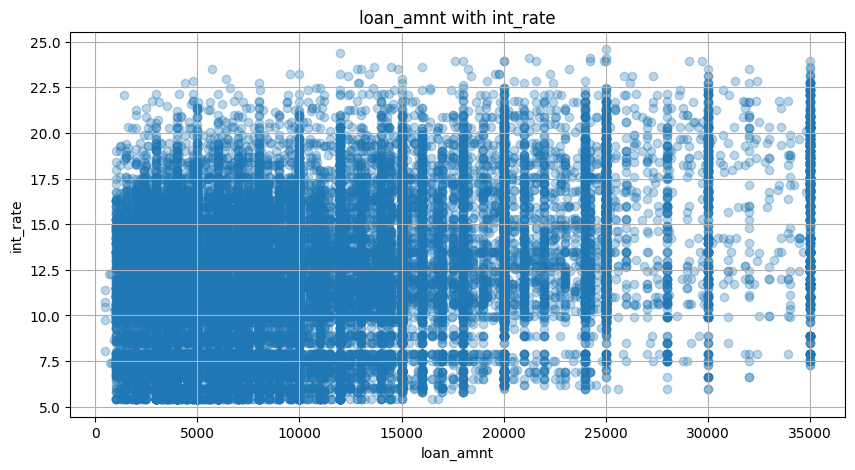

In [52]:
df2
corr_df = df2[['loan_amnt', 'int_rate']]
corr_df['int_rate'] = (corr_df['int_rate'].str.replace('%', '', regex=False).astype(float))
corr_df

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(
    corr_df['loan_amnt'],
    corr_df['int_rate'],
    alpha=0.3
)

plt.title('loan_amnt with int_rate')
plt.xlabel('loan_amnt')
plt.ylabel('int_rate')
plt.grid(True)

plt.show()

# 파일쓰기